In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
%matplotlib inline

# load dataset with fallback
url = "https://raw.githubusercontent.com/GokuMohandas/Made-With-ML/main/datasets/titanic.csv"
try:
    student_df = pd.read_csv(url)
    print('Loaded dataset from URL')
except Exception as e:
    print('Failed to load from URL:', e)
    try:
        student_df = sns.load_dataset('titanic')
        print('Loaded titanic from seaborn')
    except Exception as e2:
        print('Seaborn load failed:', e2)
        student_df = pd.DataFrame()

# normalize column names to lowercase for compatibility
if not student_df.empty:
    student_df.columns = [str(c).strip().lower() for c in student_df.columns]
    print('Columns:', student_df.columns.tolist())

student_df.head()

Failed to load from URL: HTTP Error 404: Not Found
Loaded titanic from seaborn
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


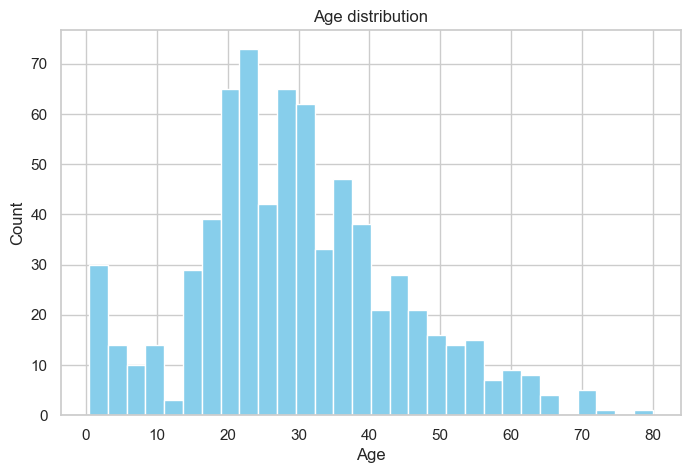

In [16]:
# Histogram of Age (lowercase column names)
plt.figure(figsize=(8,5))
if 'age' in student_df.columns:
    student_df['age'].dropna().hist(bins=30, color='skyblue')
    plt.title('Age distribution')
    plt.xlabel('Age')
    plt.ylabel('Count')
else:
    print('Column "age" not found in student_df')
plt.show()

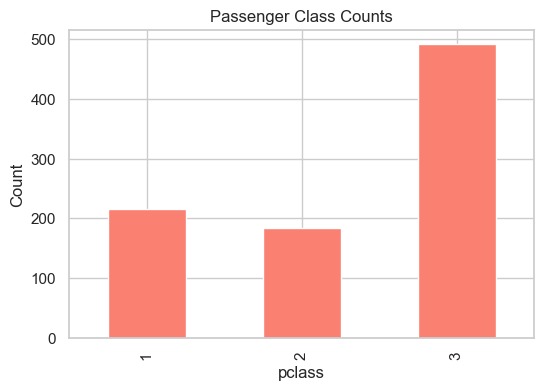

In [21]:
# Bar chart of passenger class counts (lowercase)
plt.figure(figsize=(6,4))
pclass_col = 'pclass' if 'pclass' in student_df.columns else ('class' if 'class' in student_df.columns else None)
if pclass_col:
    student_df[pclass_col].value_counts().sort_index().plot(kind='bar', color='salmon')
    plt.title('Passenger Class Counts')
    plt.xlabel(pclass_col)
    plt.ylabel('Count')
else:
    print('No pclass or class column found')
plt.show()

C:\Users\Milan\AppData\Local\Temp\ipykernel_53476\1684760400.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=pclass_col, y=fare_col, data=student_df, palette='pastel')


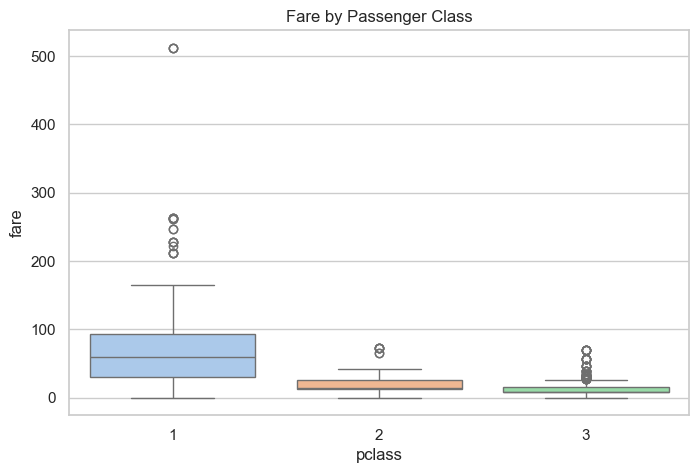

In [22]:
# Boxplot of Fare by Pclass using seaborn (lowercase)
plt.figure(figsize=(8,5))
fare_col = 'fare' if 'fare' in student_df.columns else None
pclass_col = 'pclass' if 'pclass' in student_df.columns else ('class' if 'class' in student_df.columns else None)
if fare_col and pclass_col:
    sns.boxplot(x=pclass_col, y=fare_col, data=student_df, palette='pastel')
    plt.title('Fare by Passenger Class')
else:
    print('Required columns for boxplot not found:', fare_col, pclass_col)
plt.show()

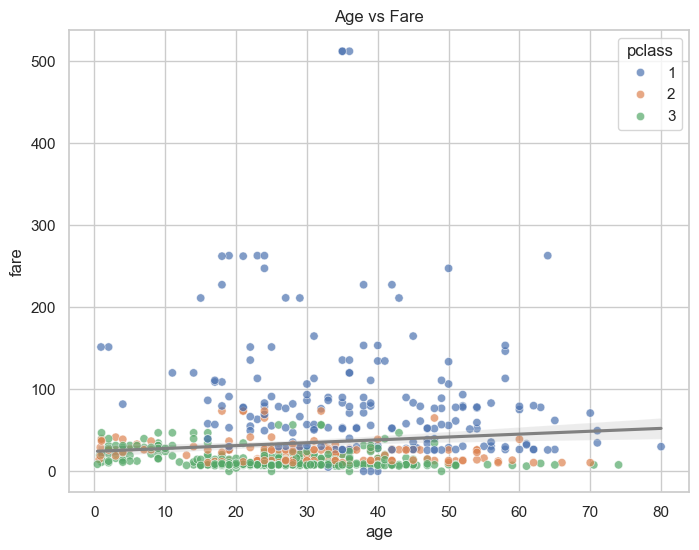

In [23]:
# Scatter plot Age vs Fare with regression overlay (lowercase)
plt.figure(figsize=(8,6))
if 'age' in student_df.columns and 'fare' in student_df.columns:
    sns.scatterplot(data=student_df, x='age', y='fare', hue=pclass_col if pclass_col in student_df.columns else None, palette='deep', alpha=0.7)
    try:
        sns.regplot(data=student_df, x='age', y='fare', scatter=False, color='grey')
    except Exception:
        pass
    plt.title('Age vs Fare')
else:
    print('Required columns for scatter not found')
plt.show()

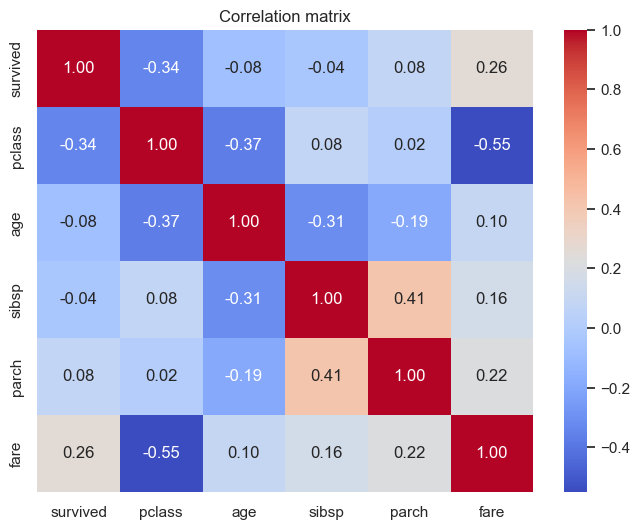

In [24]:
# Correlation heatmap (numeric columns)
corr = student_df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()